In [1]:
%matplotlib widget

In [2]:
import gdpyc
from astropy.coordinates import SkyCoord
from astroquery.vizier import Vizier
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np

In [82]:
# ============================================================
# 1a. Primary target
# ============================================================

# must match the 'name' column in ../files/source_info.txt
SOURCE_CODENAME = "NT04"
SOURCE_NAME = "NT04" # Human-readable name 
# Read sky coordinates from source_info file
_src_info = {}
with open('../files/source_info.txt') as _f:
    for _line in _f:
        if _line.startswith('#') or not _line.strip():
            continue
        _parts = _line.split()
        _src_info[_parts[0]] = (_parts[1], _parts[2])
        print(_line)
SOURCE_RA, SOURCE_DEC = _src_info[SOURCE_CODENAME]
CoordSource = SkyCoord(ra=SOURCE_RA, dec=SOURCE_DEC)
print(SOURCE_RA, SOURCE_DEC)
# Known (or estimated) distance to the source [pc].
# Used as the end-point of lines in the 3D dust visualisation.

CAS_A		23h23m27.94s	+58d48m42.4s	[-47,-38,0]	[3.3584,-0.7518,-0.0347,-0.0705]

CYG_A		19h59m28.35s	+40d44m02.1s	[3.5]		[3.3498,-1.0022,-0.2246,0.0227,0.0425]

TAU_A		05h34m31.97s	+22d00m52.1s	[-40,-25,-10,0,13]		[2.9516,-0.2173,-0.0473,-0.0674]

IC443		06h17m34.7s	+22d28m03.0s	-4.5		[1.,1.]	

CYG_X		20h30m04.8s	+40d51m36.0s	0		[1.,1.]

CYG_LOOP	20h51m00s	+30d40m00s	0		[1.,1.]

HD210839	22h11m30.6s	+59d24m52.2s	[-13.5,-34]	[1.,1.]

HD219188	23h14m00.5s	+04d59m49.6s	[-39,-9]	[1.,1.]

NRAO150		03h59m29.7s	+50d57m50.2s	[-60,-30,-25,-10,-5,10]	[1,1]

ORION		05h35m20.8s	-05d25m17.0	0		[1.,1.]

NT04		07h20m00.0s	+35d00m00.0s	0		[1.,1.]

3C190		08h01m33.6s	+14d14m42.8s	0		[1.,1.]

ABELL1914	14h25m57.4s	+37d49m54.0s	0		[1.,1.]

TAUA_CLOUDSon	05h28m09.526s	+24d12m12.8s	[-40,-25,-10,0,13]	[1.,1.]

TAUA_CLOUDSoff	05h40m20.113s	+23d46m05.94s	[-40,-25,-10,0,13]	[1.,1.]

TAUCLOUDS_HIon	05h35m38.155s	+23d11m45.11s	[-40,-25,-10,0,13]	[1.,1.]

TAUCLOUDS_HIoff	05h34m13.41s	+21d28m34.55s	[-40,-25,-10,0,13

In [83]:
## HI4PI VIZIER CATALOG NAME
catalog="J/A+A/594/A116"

coords = SkyCoord(34.0, -5.0, unit="deg")
nh_value = gdpyc.GasMap.nh(coords, nhmap="HI4PI")
print(nh_value)
gdpyc.DustMap.show_maps()

1.9430398592570645e+20 1 / cm2
Available maps:
- SFD (Schlegel, Finkbeiner & Davis 1998, ApJ, 500, 2)
- Planck13 (Planck Collaboration et al. 2013, A&A, 571, A11)


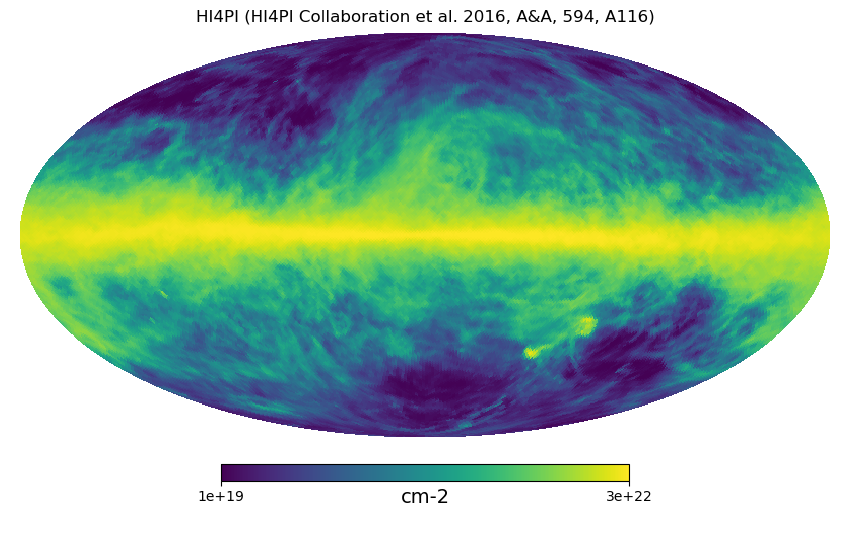

In [84]:
mapHI4PI = gdpyc.GasMap.plot_map('HI4PI')

In [85]:
mapdata = mapHI4PI.data
mapdata[np.isinf(mapdata)] = np.nan

In [86]:
np.where(~np.isnan(mapdata))

(array([  1,   1,   1, ..., 398, 398, 398], shape=(250344,)),
 array([360, 361, 362, ..., 437, 438, 439], shape=(250344,)))

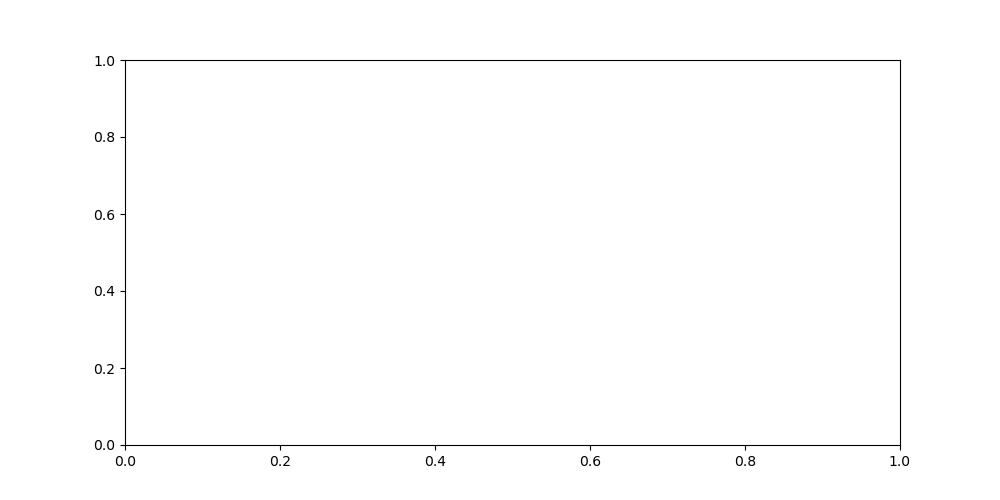

In [87]:
fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot()

In [88]:
ax.clear()
ax.imshow(np.log(mapdata[::-1]))
ax.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

In [89]:
### finding the right file to download
CoordSource, CoordSource.galactic

(<SkyCoord (ICRS): (ra, dec) in deg
     (110., 35.)>,
 <SkyCoord (Galactic): (l, b) in deg
     (183.20884193, 20.61967539)>)

In [90]:
region = Vizier().query_region(CoordSource, radius = 10*u.deg, catalog = "J/A+A/594/A116")
# cube = region[0][1]
region

TableList with 4 tables:
	'0:J/A+A/594/A116/cubes_eq' with 4 column(s) and 4 row(s) 
	'1:J/A+A/594/A116/cubes_gal' with 6 column(s) and 4 row(s) 
	'2:J/A+A/594/A116/nhi_hpx' with 6 column(s) and 49 row(s) 
	'3:J/A+A/594/A116/hpxspec' with 6 column(s) and 2 row(s) 

In [92]:
region[1]

GLON,GLAT,WCSproj,FileName,_RA.icrs,_DE.icrs
deg,deg,,,deg,deg
float32,float32,str3,str12,float64,float64
190.0,20.0,CAR,CAR_F10.fits,111.8834,28.8040
190.0,20.0,SFL,SFL_F10.fits,111.8834,28.8040
190.0,20.0,SIN,SIN_F10.fits,111.8834,28.8040
190.0,20.0,TAN,TAN_F10.fits,111.8834,28.8040


In [25]:
from astroquery.simbad import Simbad

In [42]:
Simbad().query_object("IC443")

TypeError: SimbadClass.query_object() got an unexpected keyword argument 'catalog'

In [27]:
print(CoordSource.icrs.dec.dms)

dms_tuple(d=np.float64(59.0), m=np.float64(24.0), s=np.float64(52.199999999988336))
